**1. Importa a biblioteca**

In [ ]:
import pandas as pd
import pandas as pd

pd.set_option('display.max_columns', None)      # Mostrar todas as colunas
pd.set_option('display.max_colwidth', None)     # Não cortar textos longos
pd.set_option('display.width', None)            # Ajustar largura da exibição

import numpy as np
import matplotlib.pyplot as plt
import unicodedata

In [ ]:
# Função para padronizar textos
def normalizar(texto):

    # Converte para letras minúsculas
    texto = texto.lower()

    # Remove espaços no início e fim
    texto = texto.strip()

    # Remove acentos
    texto = ''.join(
        c for c in unicodedata.normalize('NFD', texto)
        if unicodedata.category(c) != 'Mn'
    )

    # Remove pontos
    texto = texto.replace(".", "")

    return texto

**2. Importação da base**

In [ ]:
contatos = pd.read_csv("/content/contacts.csv")

**3. Mostrar/visualizar a base de dados**

In [ ]:
contatos.head(10)

In [ ]:
contatos.tail(10)

**4. Quantidade de linhas e colunas**

In [ ]:
contatos.shape

(3662, 34)

Essa base de dados possui 3653 contatos cadastrados

**5. Trazer informações sobre as colunas (nomes das colunas)**

In [ ]:
contatos.columns

Index(['First Name', 'Middle Name', 'Last Name', 'Phonetic First Name',
       'Phonetic Middle Name', 'Phonetic Last Name', 'Name Prefix',
       'Name Suffix', 'Nickname', 'File As', 'Organization Name',
       'Organization Title', 'Organization Department', 'Birthday', 'Notes',
       'Photo', 'Labels', 'E-mail 1 - Label', 'E-mail 1 - Value',
       'Phone 1 - Label', 'Phone 1 - Value', 'Phone 2 - Label',
       'Phone 2 - Value', 'Address 1 - Label', 'Address 1 - Formatted',
       'Address 1 - Street', 'Address 1 - City', 'Address 1 - PO Box',
       'Address 1 - Region', 'Address 1 - Postal Code', 'Address 1 - Country',
       'Address 1 - Extended Address', 'Relation 1 - Label',
       'Relation 1 - Value'],
      dtype='object')

**6. Conferir os tipos de dados (Dtype) de cada coluna.**

info() mostra total de linhas, colunas e baseado nisso ver se tem coluna sem valor (comparar o total de linhas 'vRangeIndex' com o total de linhas da coluna)

E os Tipos de dados Int, floalt, bool (true,false), object (str), datetime (data/hora)

In [ ]:
contatos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3662 entries, 0 to 3661
Data columns (total 34 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   First Name                    3643 non-null   object 
 1   Middle Name                   326 non-null    object 
 2   Last Name                     656 non-null    object 
 3   Phonetic First Name           3 non-null      object 
 4   Phonetic Middle Name          0 non-null      float64
 5   Phonetic Last Name            1 non-null      object 
 6   Name Prefix                   3 non-null      object 
 7   Name Suffix                   6 non-null      object 
 8   Nickname                      0 non-null      float64
 9   File As                       0 non-null      float64
 10  Organization Name             71 non-null     object 
 11  Organization Title            0 non-null      float64
 12  Organization Department       2 non-null      object 
 13  Bir

In [ ]:
contatos.dtypes

,0
First Name,object
Middle Name,object
Last Name,object
Phonetic First Name,object
Phonetic Middle Name,float64
Phonetic Last Name,object
Name Prefix,object
Name Suffix,object
Nickname,float64
File As,float64


# **Primeiras verificações**

**7. Verificar valores nulos**

In [ ]:
contatos.isnull().sum()

,0
First Name,19
Middle Name,3336
Last Name,3006
Phonetic First Name,3659
Phonetic Middle Name,3662
Phonetic Last Name,3661
Name Prefix,3659
Name Suffix,3656
Nickname,3662
File As,3662


**8. Verificar duplicados**

só considera uma linha duplicada se as 34 colunas forem exatamente iguais

In [ ]:
contatos.duplicated().sum()

np.int64(0)

# A base não possui duplicidades, porém apresenta diversas colunas vazias provenientes da exportação do Google Contatos.

# **Limpeza**

**9. Seleção das colunas relevantes**

Pelo que vimos até agora, sua base possui 34 colunas, mas muitas são informações que não serão utilizadas na análise.

Neste projeto, nosso foco é a organização e análise da base de contatos, portanto manteremos apenas as colunas que possam agregar valor à análise.

In [ ]:
contatos = contatos[["First Name", "Phone 1 - Value"]]

In [ ]:
contatos.head(10)

**10. Verificando os valores nulo novamente**

In [ ]:
contatos.isnull().sum()

,0
First Name,19
Phone 1 - Value,6


**11. Remover apenas as linhas onde o telefone principal é nulo:**

Foram identificados 6 registros sem telefone principal (Phone 1 - Value) e 19 sem nome (Firts Name). Como eles são as principais informaços de identificação dos contatos e será utilizado nas análises, esses registros foram removidos da base para garantir a consistência dos dados.

In [ ]:
contatos = contatos.dropna(subset=["Phone 1 - Value", "First Name"])
contatos.isnull().sum()

,0
First Name,0
Phone 1 - Value,0


In [ ]:
contatos.head(20)

**12. lista com todos os bairros**

Essa lista deve conter todas as formas como os bairros aparecem na base

In [ ]:
bairros = [
    "Nova III",
    "Nova II",
    "Nova I",
    "Nova",

    "Alv",
    "Band",
    "Calmon",
    "Centro",
    "Ivonete",
    "Jau",
    "Jd America",
    "Jd Aur",
    "Jd Áurea",
    "Jd Debora",
    "Jd Dulce",
    "Jd Emilia",
    "Jd Pinheiro",
    "Jd Violeta",
    "Kemel",
    "Madre",
    "Medina",
    "Monteiro",
    "Obe",
    "Per",
    "Pereta",
    "Perreli",
    "Picosse",
    "Raspadão",
    "Romana",
    "SJ",
    "Sta Helena",
    "Sta Luiza",
    "Sta Maria",
    "Varela",
    "Vl Amelia",
    "Vl Aur",
    "Vl Áurea",
    "Vl Julia",
    "Vl Júlia",
    "Vl Jau",
    "Vl Luc",
    "Vl Odete"
]

**13. Ordenar a lista**

Por quê?

Imagine: Nova III, Se a lista começar por: Nova

a função identificará apenas "Nova". Ordenando pelo tamanho, ela testa primeiro:

- Nova III
- Nova II
- Nova I- Nova

In [ ]:
# Ordena os bairros do maior para o menor
bairros = sorted(bairros, key=len, reverse=True)

In [ ]:
bairros = sorted(bairros, key=len, reverse=True)

**14. Criar a função normalizar()**

- Converte para minúsculas
- Remove espaços
- Remove acentos
- Remove pontos

In [ ]:
# Biblioteca utilizada para remover acentos
import unicodedata

# Função para padronizar textos
def normalizar(texto):

    # Verifica se o valor é nulo
    if pd.isna(texto):
        return ""

    # Converte para string
    texto = str(texto)

    # Converte para letras minúsculas
    texto = texto.lower()

    # Remove espaços no início e no fim
    texto = texto.strip()

    # Remove acentos
    texto = ''.join(
        c for c in unicodedata.normalize('NFD', texto)
        if unicodedata.category(c) != 'Mn'
    )

    # Remove pontos
    texto = texto.replace(".", "")

    return texto

**Testar a função**

In [ ]:
print(normalizar("SJ Ivanice"))
print(normalizar("Vl Júlia"))
print(normalizar("Vl. Luc"))
print(normalizar("Jd Áurea"))

sj ivanice
vl julia
vl luc
jd aurea


**15. Criar a função extrair_bairro()**

Recebe um contato -> Padroniza o texto -> Percorre todos os bairros -> Compara usando startswith() ->

In [ ]:
# Função para identificar o bairro no início do campo "First Name"
def extrair_bairro(nome):

    # Verifica se o valor é nulo
    if pd.isna(nome):
        return None

    # Padroniza o texto do contato
    nome_normalizado = normalizar(nome)

    # Percorre a lista de bairros
    for bairro in bairros:

        # Padroniza o bairro para a comparação
        bairro_normalizado = normalizar(bairro)

        # Verifica se o texto começa com esse bairro
        if nome_normalizado.startswith(bairro_normalizado):

            # Retorna o bairro encontrado
            return bairro

    # Caso nenhum bairro seja encontrado
    return None

**16. Criar a coluna bairro**

In [ ]:
# Cria a coluna "bairro" identificando o bairro no início do campo "First Name"
contatos["bairro"] = contatos["First Name"].apply(extrair_bairro)

**Verificar o resultado**

In [ ]:
contatos[["First Name", "bairro"]].tail(50)

**17. Avaliar a qualidade da extração**

Quantos bairros foram encontrados?

In [ ]:
contatos["bairro"].count()

np.int64(2197)

Quantos ficaram sem bairro?

In [ ]:
contatos["bairro"].isna().sum()

np.int64(1441)

Qual o percentual de sucesso?

In [ ]:
percentual = contatos["bairro"].notna().mean() * 100

print(f"Percentual de bairros identificados: {percentual:.2f}%")

Percentual de bairros identificados: 60.39%


- 3.647 contatos na base.
- 2.211 contatos com bairro identificado (60,43%).
- 1.436 contatos sem bairro (39,57%).

**18. Descobrir apenas os casos problemáticos**

Investigar somente os contatos que não tiveram bairro identificado

In [ ]:
contatos.loc[contatos["bairro"].isna(), ["First Name"]].sample(50, random_state=100)

Os contatos que sobraram não têm bairro

**19. Quantos contatos possuem bairro identificado?**

In [ ]:
contatos["bairro"].value_counts()

,count
bairro,
Nova,416
Per,204
Madre,183
Obe,166
Varela,161
Calmon,117
Alv,83
Vl Aur,71
Nova I,63


Insight - Foram identificados bairros iguais, mas com nomes escritos de formas diferentes

**20. Dicionário - Padronização dos bairros, deixando todos escritos por extenso**

In [ ]:
padronizacao_bairros = {

    # Jardim
    "Jd Aur": "Jardim Áurea",
    "Jardim Áurea": "Jardim Áurea",
    "Jd Áurea": "Jardim Áurea",

    "Jd Debora": "Jardim Débora",

    "Jd Emilia": "Jardim Emília",

    "Jd Pinheiro": "Jardim Pinheiro",

    "Jd Violeta": "Jardim Violeta",

    "Jd America": "Jardim América",

    # Jaú
    "Jau": "Jaú",
    "Vl Jau": "Jaú",
    "Vila Jaú": "Jaú",

    # São José
    "SJ": "São José",

    # Santa
    "Sta Helena": "Santa Helena",

    "Sta Luiza": "Santa Luiza",

    "Sta Maria": "Santa Maria",

    # Vila
    "Vl Amelia": "Vila Amélia",

    "Vl Odete": "Vila Odete",

    "Vl Aur": "Vila Áurea",
    "Vl Áurea": "Vila Áurea",

    "Vl Julia": "Vila Júlia",
    "Vl Júlia": "Vila Júlia",

    "Vl Luc": "Vila Lúcia",


    # Nova Poá
    "Nova": "Nova Poá",
    "Nova I": "Nova Poá I",
    "Nova II": "Nova Poá II",
    "Nova III": "Nova Poá III",

    #Perracini
    "Per": "Perracini",

    #Alvorada
    "Alv": "Alvorada",

    #Bandeirantes
    "Band": "Bandeirantes",

    #Obelisco
    "Obe": "Obelisco",

}

**21. Padronizar os bairros**

In [ ]:
contatos["bairro_padronizado"] = contatos["bairro"].replace(padronizacao_bairros)

In [ ]:
sorted(contatos["bairro_padronizado"].dropna().unique())

['Alvorada',
 'Bandeirantes',
 'Calmon',
 'Centro',
 'Ivonete',
 'Jardim América',
 'Jardim Débora',
 'Jardim Emília',
 'Jardim Pinheiro',
 'Jardim Violeta',
 'Jardim Áurea',
 'Jaú',
 'Kemel',
 'Madre',
 'Medina',
 'Monteiro',
 'Nova Poá',
 'Nova Poá I',
 'Nova Poá II',
 'Nova Poá III',
 'Obelisco',
 'Pereta',
 'Perracini',
 'Perreli',
 'Picosse',
 'Raspadão',
 'Romana',
 'Santa Helena',
 'Santa Luiza',
 'Santa Maria',
 'São José',
 'Varela',
 'Vila Amélia',
 'Vila Júlia',
 'Vila Lúcia',
 'Vila Odete',
 'Vila Áurea']

**22. Quantidade de contatos por bairro**

Quais bairros concentram mais contatos?

In [ ]:
contatos["bairro_padronizado"].value_counts()

,count
bairro_padronizado,
Nova Poá,416
Perracini,204
Madre,183
Obelisco,166
Varela,161
Calmon,117
Alvorada,83
Vila Áurea,73
Nova Poá I,63


**23. Criar a coluna zona**

In [ ]:
zona_bairros = {

    # Parte de cima
    "Nova Poá": "Parte de cima",
    "Nova Poá I": "Parte de cima",
    "Calmon": "Parte de cima",
    "Nova Poá II": "Parte de cima",
    "Nova Poá III": "Parte de cima",
    "Obelisco": "Parte de cima",
    "Raspadão": "Parte de cima",
    "Vila Amélia": "Parte de cima",
    "Jardim Débora": "Parte de cima",
    "Jardim Emília": "Parte de cima",
    "Jardim Pinheiro": "Parte de cima",
    "Romana": "Parte de cima",
    "Madre": "Parte de cima",
    "Santa Maria": "Parte de cima",
    "Pereta": "Parte de cima",
    "Vila Odete": "Parte de cima",

    # Parte de baixo
    "Alvorada": "Parte de baixo",
    "Monteiro": "Parte de baixo",
    "Bandeirantes": "Parte de baixo",
    "Centro": "Parte de baixo",
    "Jardim América": "Parte de baixo",
    "Jardim Áurea": "Parte de baixo",
    "Jaú": "Parte de baixo",
    "Perracini": "Parte de baixo",
    "Perreli": "Parte de baixo",
    "Picosse": "Parte de baixo",
    "Kemel": "Parte de baixo",
    "Medina": "Parte de baixo",
    "Santa Helena": "Parte de baixo",
    "Santa Luiza": "Parte de baixo",
    "São José": "Parte de baixo",
    "Varela": "Parte de baixo",
    "Vila Áurea": "Parte de baixo",
    "Vila Júlia": "Parte de baixo",
    "Vila Lúcia": "Parte de baixo",
    "Ivonete": "Parte de baixo",
    "Jardim Violeta":"Parte de baixo",
    "Vila Lucia": "Parte de baixo",
    "Jd Áurea": "Parte de baixo"}

**24. Criar a coluna**

In [ ]:
# Cria a coluna "zona"
contatos["zona"] = contatos["bairro_padronizado"].map(zona_bairros)

**25. Conferir o resultado**

In [ ]:
contatos[ ["bairro_padronizado", "zona"]].drop_duplicates().sort_values("bairro_padronizado")

,bairro_padronizado,zona
65,Alvorada,Parte de baixo
212,Bandeirantes,Parte de baixo
313,Calmon,Parte de cima
472,Centro,Parte de baixo
925,Ivonete,Parte de baixo
970,Jardim América,Parte de baixo
1050,Jardim Débora,Parte de cima
1061,Jardim Emília,Parte de cima
1109,Jardim Pinheiro,Parte de cima
1137,Jardim Violeta,Parte de baixo


# **Análise Exploratória dos Dados (EDA)**

**26. Informações gerais da base**

In [ ]:
# Total de contatos
total_contatos = len(contatos)

# Contatos com bairro identificado
contatos_com_bairro = contatos["bairro_padronizado"].notna().sum()

# Contatos sem bairro
contatos_sem_bairro = contatos["bairro_padronizado"].isna().sum()

# Quantidade de bairros identificados
quantidade_bairros = contatos["bairro_padronizado"].nunique()

# Quantidade de contatos na parte de cima
parte_cima = (contatos["zona"] == "Parte de cima").sum()

# Quantidade de contatos na parte de baixo
parte_baixo = (contatos["zona"] == "Parte de baixo").sum()

# Percentual de cobertura
percentual_cobertura = (contatos_com_bairro / total_contatos) * 100

In [ ]:
print(f"Total de contatos: {total_contatos}")
print(f"Contatos com bairro: {contatos_com_bairro}")
print(f"Contatos sem bairro: {contatos_sem_bairro}")
print(f"Quantidade de bairros identificados: {quantidade_bairros}")
print(f"Parte de cima: {parte_cima}")
print(f"Parte de baixo: {parte_baixo}")

Total de contatos: 3638
Contatos com bairro: 2197
Contatos sem bairro: 1441
Quantidade de bairros identificados: 37
Parte de cima: 1194
Parte de baixo: 1003


**27. Análise Nova Poá**

Já que foi separado 4

In [ ]:
contatos[
    contatos["bairro_padronizado"].str.contains("Nova", na=False)
]["bairro_padronizado"].value_counts()

,count
bairro_padronizado,
Nova Poá,416
Nova Poá I,63
Nova Poá III,37
Nova Poá II,7


Poá possui **34 bairros**, mas para fins de análise estratégica a Nova Poá (maior bairro) foi dividida em quatro regiões (Nova Poá, Nova Poá I, Nova Poá II e Nova Poá III).

**28. Top 10 bairros**

In [ ]:
contatos["bairro_padronizado"].value_counts().head(10)

,count
bairro_padronizado,
Nova Poá,416
Perracini,204
Madre,183
Obelisco,166
Varela,161
Calmon,117
Alvorada,83
Vila Áurea,73
Nova Poá I,63


# **Visualizações**

**29. Distribuição de contatos por bairro**

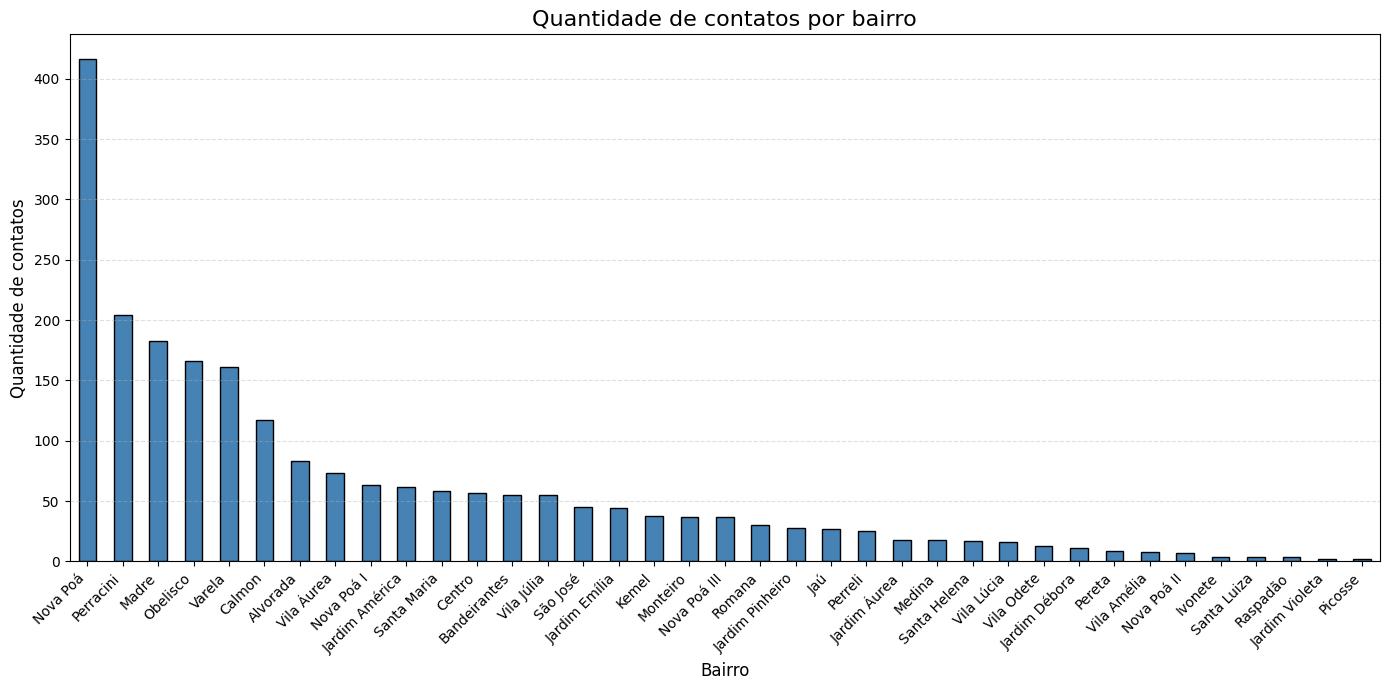

In [ ]:
import matplotlib.pyplot as plt

contatos_por_bairro = (
    contatos["bairro_padronizado"]
    .value_counts()
    .sort_values(ascending=False)
)

plt.figure(figsize=(14,7))

contatos_por_bairro.plot(
    kind="bar",
    color="steelblue",
    edgecolor="black"
)

plt.title("Quantidade de contatos por bairro", fontsize=16)
plt.xlabel("Bairro", fontsize=12)
plt.ylabel("Quantidade de contatos", fontsize=12)

plt.xticks(rotation=45, ha="right")

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()

plt.show()
plt.show()

**30. Distribuição por zona**

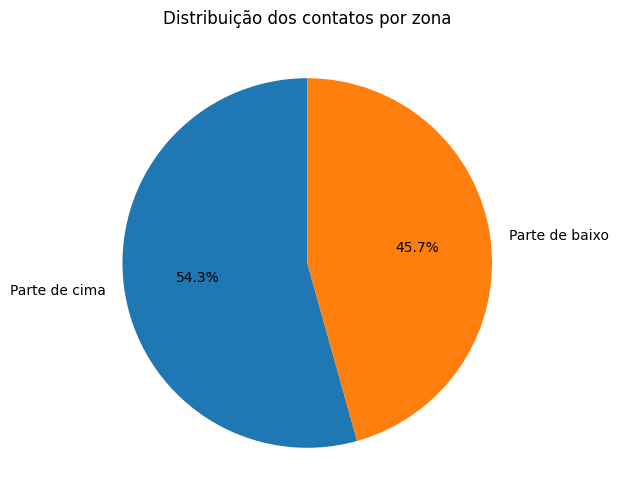

In [ ]:
zona = contatos["zona"].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    zona,
    labels=zona.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Distribuição dos contatos por zona")

plt.show()

**31. Distribuição da Nova Poá**

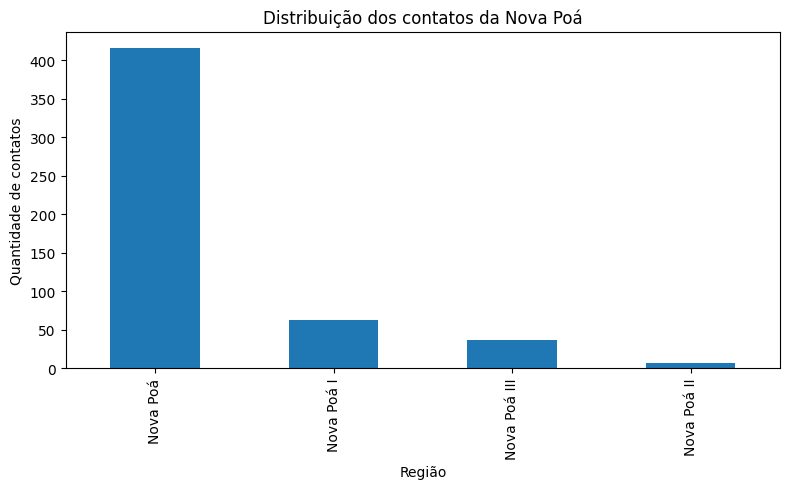

In [ ]:
nova = contatos[
    contatos["bairro_padronizado"].str.contains("Nova", na=False)
]

nova["bairro_padronizado"].value_counts().plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Distribuição dos contatos da Nova Poá")

plt.xlabel("Região")

plt.ylabel("Quantidade de contatos")

plt.tight_layout()

plt.show()

**32. Contatos por bairro e zona**

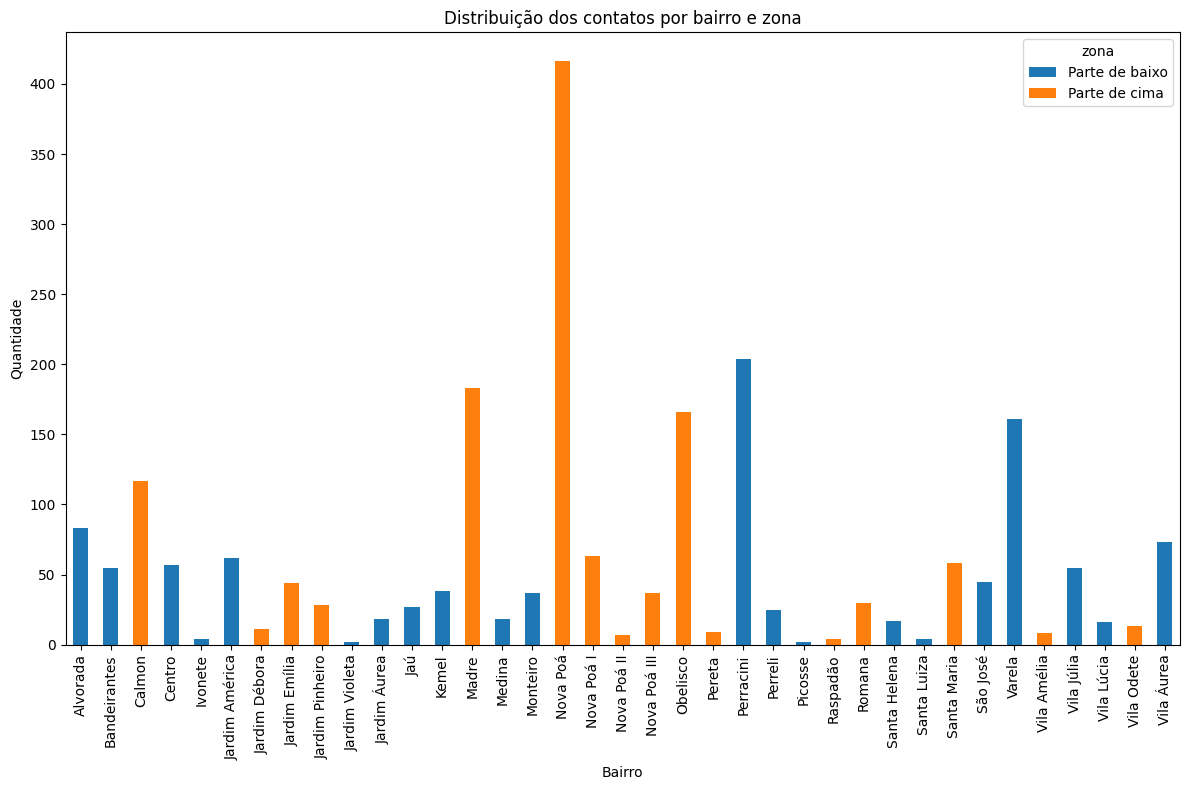

In [ ]:
tabela = pd.crosstab(
    contatos["bairro_padronizado"],
    contatos["zona"]
)

tabela.plot(
    kind="bar",
    stacked=True,
    figsize=(12,8)
)

plt.title("Distribuição dos contatos por bairro e zona")

plt.xlabel("Bairro")

plt.ylabel("Quantidade")

plt.tight_layout()

plt.show()

# **Exportação**

**33. Exportação da base tratada**

In [ ]:
contatos.to_csv(
    "contatos_tratados.csv",
    index=False,
    encoding="utf-8-sig")

O navegador fará o download automaticamente

In [ ]:
from google.colab import files

files.download("contatos_tratados.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# **Versão anonimizada**

**Cópia da base**

In [ ]:
contatos_portfolio = contatos.copy()

**Criar nomes fictícios**

In [ ]:
contatos_portfolio["First Name"] = [
    f"Contato {i:04d}"
    for i in range(1, len(contatos_portfolio)+1)]

In [ ]:
contatos_portfolio

**Criar telefones fictícios**

In [ ]:
contatos_portfolio["Phone 1 - Value"] = [
    f"+55110000{i:04d}"
    for i in range(1, len(contatos_portfolio)+1)]

In [ ]:
contatos_portfolio

,First Name,Phone 1 - Value,bairro,bairro_padronizado,zona
0,Contato 0001,+551100000001,None,None,NaN
1,Contato 0002,+551100000002,Kemel,Kemel,Parte de baixo
3,Contato 0003,+551100000003,None,None,NaN
4,Contato 0004,+551100000004,None,None,NaN
5,Contato 0005,+551100000005,None,None,NaN
...,...,...,...,...,...
3656,Contato 3634,+551100003634,None,None,NaN
3658,Contato 3635,+551100003635,None,None,NaN
3659,Contato 3636,+551100003636,None,None,NaN
3660,Contato 3637,+551100003637,None,None,NaN


**Remover colunas que ainda possam identificar alguém**

In [ ]:
contatos_portfolio = contatos_portfolio.drop(
    columns=[
        "bairro",
        "nome"
    ],
    errors="ignore"
)

In [ ]:
contatos_portfolio

,First Name,Phone 1 - Value,bairro_padronizado,zona
0,Contato 0001,+551100000001,None,NaN
1,Contato 0002,+551100000002,Kemel,Parte de baixo
3,Contato 0003,+551100000003,None,NaN
4,Contato 0004,+551100000004,None,NaN
5,Contato 0005,+551100000005,None,NaN
...,...,...,...,...
3656,Contato 3634,+551100003634,None,NaN
3658,Contato 3635,+551100003635,None,NaN
3659,Contato 3636,+551100003636,None,NaN
3660,Contato 3637,+551100003637,None,NaN


**Salvar a versão do portfólio**

In [ ]:
contatos_portfolio.to_csv(
    "contatos_portfolio.csv",
    index=False,
    encoding="utf-8-sig")

O navegador fará o download automaticamente

In [ ]:
from google.colab import files

files.download("contatos_portfolio.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

**Este projeto foi desenvolvido a partir de uma base real de contatos. Para preservar a privacidade e atender às boas práticas de proteção de dados, foi disponibilizada uma versão anonimizada, mantendo a estrutura, as distribuições e os atributos necessários para reproduzir todas as análises e visualizações.**